# Genomic Selection Pipeline: Bayesian Benchmarks & Neural Network Consensus
This notebook walks through the steps of predicting breeding values using Bayesian Alphabet models (BayesA, BayesB, BayesC), constructing a consensus selection index for the top 10% 'elite' lines across four environments, and utilizing a Neural Network on PCA-reduced marker data to replicate the consensus decisions.

In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
yield_df = pd.read_csv('yieldata.csv')
marker_df = pd.read_csv('markerMatrix.csv')

X = marker_df.drop('gid', axis=1).values
Y = yield_df.values  # 599 x 4 environments


## 1. Custom Gibbs Sampler for Bayesian Alphabet Models
We implement a custom Markov Chain Monte Carlo (MCMC) sampler to estimate marker effects for BayesA, BayesB, and BayesC. BayesB and BayesC incorporate a prior probability ($\pi = 0.90$) for variable selection.

In [2]:
def run_bayesian_alphabet_fast(X_sc, y_c, xpx, model='BayesA', pi=0.9, n_iter=600, burn_in=200):
    n, p = X_sc.shape
    b = np.zeros(p)
    var_e = np.var(y_c) * 0.5
    
    if model in ['BayesA', 'BayesB']:
        var_b = np.ones(p) * (np.var(y_c) / p)
    else:
        var_b = np.var(y_c) / p
        
    df_e = 4.0
    S_e = var_e * (df_e - 2.0) / df_e
    df_b = 4.0
    S_b = (np.var(y_c) / p) * (df_b - 2.0) / df_b
    
    e = y_c.copy()
    b_samples = np.zeros((n_iter - burn_in, p))
    
    for it in range(n_iter):
        for j in range(p):
            rhs = np.dot(X_sc[:, j], e) + xpx[j] * b[j]
            v_b = var_b[j] if model in ['BayesA', 'BayesB'] else var_b
            
            lhs = xpx[j] + var_e / v_b
            b_mean = rhs / lhs
            b_var = var_e / lhs
            
            include_marker = True
            if model in ['BayesB', 'BayesC']:
                log_delta0 = -0.5 * np.log(var_e)
                log_delta1 = -0.5 * np.log(lhs * v_b) + 0.5 * (rhs**2 / (var_e * lhs))
                max_val = max(log_delta1, log_delta0)
                prob_inc = (1 - pi) * np.exp(log_delta1 - max_val)
                prob_exc = pi * np.exp(log_delta0 - max_val)
                prob_inc = prob_inc / (prob_inc + prob_exc)
                include_marker = (np.random.uniform() < prob_inc)
            
            b_old = b[j]
            if include_marker:
                b[j] = np.random.normal(b_mean, np.sqrt(b_var))
            else:
                b[j] = 0.0
                
            e = e - X_sc[:, j] * (b[j] - b_old)
            
            if model in ['BayesA', 'BayesB']:
                if b[j] != 0:
                    var_b[j] = (S_b * df_b + b[j]**2) / np.random.chisquare(df_b + 1)
                else:
                    var_b[j] = (S_b * df_b) / np.random.chisquare(df_b)
        
        if model == 'BayesC':
            n_inc = np.sum(b != 0)
            if n_inc > 0:
                var_b = (S_b * df_b + np.sum(b**2)) / np.random.chisquare(df_b + n_inc)
            else:
                var_b = (S_b * df_b) / np.random.chisquare(df_b)
                
        var_e = (S_e * df_e + np.sum(e**2)) / np.random.chisquare(df_e + n)
        
        if it >= burn_in:
            b_samples[it - burn_in, :] = b
            
    return np.mean(b_samples, axis=0)


## 2. Generate Bayesian Benchmarks
We standardize the marker matrix and iterate over all 4 environments, computing Genomic Estimated Breeding Values (GEBVs) for each model.

In [3]:
# Pre-scale X
X_mean = np.mean(X, axis=0)
X_sd = np.std(X, axis=0)
X_sd[X_sd == 0] = 1
X_sc = (X - X_mean) / X_sd
xpx = np.sum(X_sc**2, axis=0)

preds_dict = {env: {m: [] for m in ['BayesA', 'BayesB', 'BayesC']} for env in range(4)}

print("Generating GEBVs (this takes a moment)...")
for env in range(4):
    y = Y[:, env]
    y_mean = np.mean(y)
    y_c = y - y_mean
    
    for m in ['BayesA', 'BayesB', 'BayesC']:
        b_hat = run_bayesian_alphabet_fast(X_sc, y_c, xpx, model=m, n_iter=500, burn_in=150)
        y_pred = y_mean + np.dot(X_sc, b_hat)
        preds_dict[env][m] = y_pred
    print(f"Environment {env+1} completed.")


Generating GEBVs (this takes a moment)...
Environment 1 completed.
Environment 2 completed.
Environment 3 completed.
Environment 4 completed.


## 3. Consensus Decision & PCA Dimensionality Reduction
We average the predictions from BayesA, B, and C to create a 'consensus' prediction. We select the top 10% from this consensus as our elite binary target (1 = Selected, 0 = Not Selected). Simultaneously, we reduce the marker matrix using PCA with a 60% explained variance cutoff.

In [4]:
binary_targets = {}
for env in range(4):
    y_pred_consensus = (preds_dict[env]['BayesA'] + preds_dict[env]['BayesB'] + preds_dict[env]['BayesC']) / 3.0
    cutoff_val = np.percentile(y_pred_consensus, 90) # Top 10%
    binary_targets[env] = (y_pred_consensus >= cutoff_val).astype(int)

pca = PCA(n_components=0.60, random_state=42)
X_pca = pca.fit_transform(X_sc)
print(f"PCA (60% variance cutoff) extracted {X_pca.shape[1]} components.")


PCA (60% variance cutoff) extracted 39 components.


## 4. Neural Network Classification
We train a Multi-Layer Perceptron (MLP) Classifier using the PCA components to predict the consensus selection decisions.

In [5]:
nn_results = []
preds_nn_all = {}

for env in range(4):
    y_bin = binary_targets[env]
    
    # 80/20 Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y_bin, test_size=0.2, random_state=42, stratify=y_bin)
    
    # Train MLP
    mlp = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', max_iter=1000, random_state=42)
    mlp.fit(X_train, y_train)
    
    # Predict
    y_pred_test = mlp.predict(X_test)
    preds_nn_all[env] = mlp.predict(X_pca) # Predict for full dataset for later overlap comparison
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    nn_results.append({'Environment': f"E{env+1}", 'Accuracy': acc, 'F1-Score': f1})

res_df = pd.DataFrame(nn_results)
print("Neural Network (PCA 60%) Classification Results on Consensus Target:")
display(res_df)


Neural Network (PCA 60%) Classification Results on Consensus Target:


,Environment,Accuracy,F1-Score
0,E1,0.941667,0.666667
1,E2,0.941667,0.666667
2,E3,0.925000,0.571429
3,E4,0.958333,0.800000


## 5. Selection Overlap Analysis (Recall)
Finally, we analyze how well the NN approximated the Bayesian consensus, and how well both methods identified the true top 10% elite lines from the empirical yield data.

Overlap of Selected Decisions (Recall of Elite lines):


,Environment,Consensus vs True Elite,NN vs Consensus Elite,NN vs True Elite
0,E1,0.516667,0.916667,0.500000
1,E2,0.566667,0.916667,0.533333
2,E3,0.550000,0.900000,0.500000
3,E4,0.616667,0.966667,0.600000


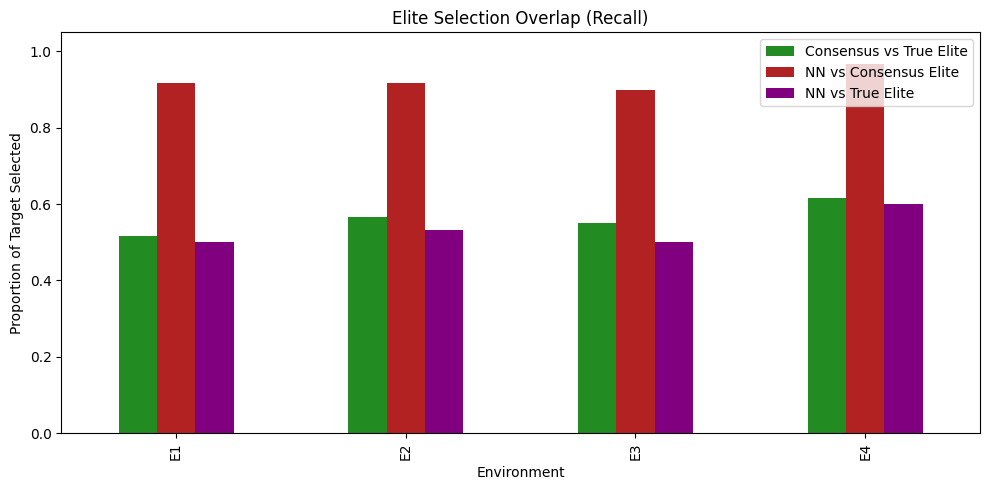

In [6]:
overlap_stats = []
for env in range(4):
    true_y = Y[:, env]
    true_cutoff = np.percentile(true_y, 90)
    true_bin = (true_y >= true_cutoff).astype(int)
    
    consensus_bin = binary_targets[env]
    nn_bin = preds_nn_all[env]
    
    overlap_consensus_true = np.sum((consensus_bin == 1) & (true_bin == 1)) / np.sum(true_bin == 1)
    overlap_nn_true = np.sum((nn_bin == 1) & (true_bin == 1)) / np.sum(true_bin == 1)
    overlap_nn_consensus = np.sum((nn_bin == 1) & (consensus_bin == 1)) / np.sum(consensus_bin == 1)
    
    overlap_stats.append({
        'Environment': f"E{env+1}",
        'Consensus vs True Elite': overlap_consensus_true,
        'NN vs Consensus Elite': overlap_nn_consensus,
        'NN vs True Elite': overlap_nn_true
    })

overlap_df = pd.DataFrame(overlap_stats)
print("Overlap of Selected Decisions (Recall of Elite lines):")
display(overlap_df)

# Plot the overlap
overlap_df.plot(x='Environment', kind='bar', figsize=(10, 5), color=['forestgreen', 'firebrick', 'purple'])
plt.title('Elite Selection Overlap (Recall)')
plt.ylabel('Proportion of Target Selected')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()
